In [22]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"C:\Users\Home\OneDrive\VSCode Projects\healthcare insurance cost analysis\insurance raw.csv")
print(df.head())


   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [23]:
# Data Inspection

print(df.info())
print()
print(df.describe())
print()
print(df.isnull().sum())  #check for missing values
print()
print(df.columns)
print()
print(df.dtypes)          #check data types
print()
print(df.shape)
print()
print(df.nunique())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
ma

In [25]:
# Data Cleaning

duplicates = df[df.duplicated(keep=False)]   #identify duplicate rows
print(duplicates)
print()

df = df.drop_duplicates()     #remove duplicates
print(df.shape)               #validate row count
print()


numeric_cols = df.select_dtypes(include=['number']).columns #select numeric columns

for col in numeric_cols:
    skew = df[col].skew()   #calculate skewness
    print(f"\nSkewness of '{col}': {skew:.3f}")   #3-decimal float

    if abs(skew) > 1:
        print(f"→ '{col}' is highly skewed.")     #interpret skewness
    elif 0.5 < abs(skew) <= 1:
        print(f"→ '{col}' is moderately skewed.")
    else:
        print(f"→ '{col}' is approximately symmetric.")

Empty DataFrame
Columns: [age, sex, bmi, children, smoker, region, charges]
Index: []

(1337, 7)


Skewness of 'age': 0.055
→ 'age' is approximately symmetric.

Skewness of 'bmi': 0.284
→ 'bmi' is approximately symmetric.

Skewness of 'children': 0.937
→ 'children' is moderately skewed.

Skewness of 'charges': 1.515
→ 'charges' is highly skewed.


In [26]:
# Detect outliers using the IQR method 
iqr_cols = [col for col in numeric_cols if col != 'charges']  #exclude target variable

all_outlier_indices = set()       #empty set for outlier indices

for col in iqr_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    mask = (df[col] < lower) | (df[col] > upper)  #identify outliers
    outliers = df[mask]

    all_outlier_indices.update(outliers.index)    #add indices to the set

    # Display summary
    print(f"\nColumn: {col}")  
    print(f"Outlier count: {len(outliers)}")      
    print(outliers)   




Column: age
Outlier count: 0
Empty DataFrame
Columns: [age, sex, bmi, children, smoker, region, charges]
Index: []

Column: bmi
Outlier count: 9
      age     sex    bmi  children smoker     region      charges
116    58    male  49.06         0     no  southeast  11381.32540
286    46  female  48.07         2     no  northeast   9432.92530
401    47    male  47.52         1     no  southeast   8083.91980
543    54  female  47.41         0    yes  southeast  63770.42801
847    23    male  50.38         1     no  southeast   2438.05520
860    37  female  47.60         2    yes  southwest  46113.51100
1047   22    male  52.58         1    yes  southeast  44501.39820
1088   52    male  47.74         1     no  southeast   9748.91060
1317   18    male  53.13         0     no  southeast   1163.46270

Column: children
Outlier count: 0
Empty DataFrame
Columns: [age, sex, bmi, children, smoker, region, charges]
Index: []


In [27]:
# Feature Engineering

#  Log-transform 'charges' to reduce skewness
df['log_charges'] = np.log1p(df['charges'])
print("First few rows of 'charges' and 'log_charges':")
print(df[['charges', 'log_charges']].head(), "\n")

log_skew = df['log_charges'].skew()  #skewness of the transformed target
print(f"Skewness of 'log_charges': {log_skew:.3f}\n")


# Create BMI categories
df['bmi_category'] = pd.cut(
    df['bmi'],
    bins=[0, 18.5, 25, 30, np.inf],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']  #category labels
)
print("bmi_category value counts:")
print(df['bmi_category'].value_counts())


# One-Hot Encode Categorical Variables
categorical_cols = ['sex', 'smoker', 'region', 'bmi_category']

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)   

print("\nDataset after one-hot encoding:")  #first few rows after encoding
print(df.head())



First few rows of 'charges' and 'log_charges':
       charges  log_charges
0  16884.92400     9.734236
1   1725.55230     7.453882
2   4449.46200     8.400763
3  21984.47061     9.998137
4   3866.85520     8.260455 

Skewness of 'log_charges': -0.090

bmi_category value counts:
bmi_category
Obese          704
Overweight     386
Normal         226
Underweight     21
Name: count, dtype: int64

Dataset after one-hot encoding:
   age     bmi  children      charges  log_charges  sex_male  smoker_yes  \
0   19  27.900         0  16884.92400     9.734236     False        True   
1   18  33.770         1   1725.55230     7.453882      True       False   
2   28  33.000         3   4449.46200     8.400763      True       False   
3   33  22.705         0  21984.47061     9.998137      True       False   
4   32  28.880         0   3866.85520     8.260455      True       False   

   region_northwest  region_southeast  region_southwest  bmi_category_Normal  \
0             False             Fals

In [ ]:
#Download cleaned dataset
df.to_csv(r"C:\Users\Home\OneDrive\VSCode Projects\healthcare insurance cost analysis\insurance cleaned.csv", index=False)

In [28]:
#Load cleaned dataset

df = pd.read_csv(r"C:\Users\Home\OneDrive\VSCode Projects\healthcare insurance cost analysis\insurance cleaned.csv")
print(df.info())
print()
print(df.head())
print()
print(df.describe()) #descriptive statistics
print()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1337 entries, 0 to 1336
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      1337 non-null   int64  
 1   bmi                      1337 non-null   float64
 2   children                 1337 non-null   int64  
 3   charges                  1337 non-null   float64
 4   log_charges              1337 non-null   float64
 5   sex_male                 1337 non-null   bool   
 6   smoker_yes               1337 non-null   bool   
 7   region_northwest         1337 non-null   bool   
 8   region_southeast         1337 non-null   bool   
 9   region_southwest         1337 non-null   bool   
 10  bmi_category_Normal      1337 non-null   bool   
 11  bmi_category_Overweight  1337 non-null   bool   
 12  bmi_category_Obese       1337 non-null   bool   
dtypes: bool(8), float64(3), int64(2)
memory usage: 62.8 KB
None

   age     bmi  c

In [29]:
# Descriptive Statistics: Average Charges

#  Average charges by age group
age_bins = [0, 18, 30, 45, 60, 100]
age_labels = ['0-18', '19-30', '31-45', '46-60', '61+']     #age group labels
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels)   

avg_charges_by_age_group = df.groupby('age_group')['charges'].mean()  
print("Average charges by age group:")
print(avg_charges_by_age_group, "\n")

#  Average charges by smoker status
smoker_status = df['smoker_yes'].map({True: 'Yes', False: 'No'})
avg_charges_by_smoker = df.groupby(smoker_status)['charges'].mean()
smoker_counts = smoker_status.value_counts()
print("Average charges by smoker status:")
print(avg_charges_by_smoker, "\n")

#  Average charges by region
def reconstruct_region(row):      # reconstruct from one-hot encoded columns
    if row['region_northwest']:
        return 'northwest'
    elif row['region_southeast']:
        return 'southeast'
    elif row['region_southwest']:
        return 'southwest'
    else:
        return 'northeast'

region = df.apply(reconstruct_region, axis=1)
avg_charges_by_region = df.groupby(region)['charges'].mean()
print("Average charges by region:")
print(avg_charges_by_region, "\n")

# Average charges by gender
gender = df['sex_male'].map({True: 'male', False: 'female'})  
avg_charges_by_gender = df.groupby(gender)['charges'].mean()
print("Average charges by gender:")
print(avg_charges_by_gender, "\n")

# Average charges by BMI category
def bmi_category(bmi):      #reconstruct from BMI values
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25:
        return 'Normal'
    elif bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

bmi_group = df['bmi'].apply(bmi_category)
avg_charges_by_bmi_group = df.groupby(bmi_group)['charges'].mean()
print("Average charges by BMI group:")
print(avg_charges_by_bmi_group, "\n")

Average charges by age group:
age_group
0-18      7086.217556
19-30     9844.718012
31-45    12647.455654
46-60    16340.993846
61+      21063.163398
Name: charges, dtype: float64 

Average charges by smoker status:
smoker_yes
No      8440.660307
Yes    32050.231832
Name: charges, dtype: float64 

Average charges by region:
northeast    13406.384516
northwest    12450.840844
southeast    14735.411438
southwest    12346.937377
Name: charges, dtype: float64 

Average charges by gender:
sex_male
female    12569.578844
male      13974.998864
Name: charges, dtype: float64 

Average charges by BMI group:
bmi
Normal         10409.337709
Obese          15572.041945
Overweight     10987.509891
Underweight     8852.200585
Name: charges, dtype: float64 



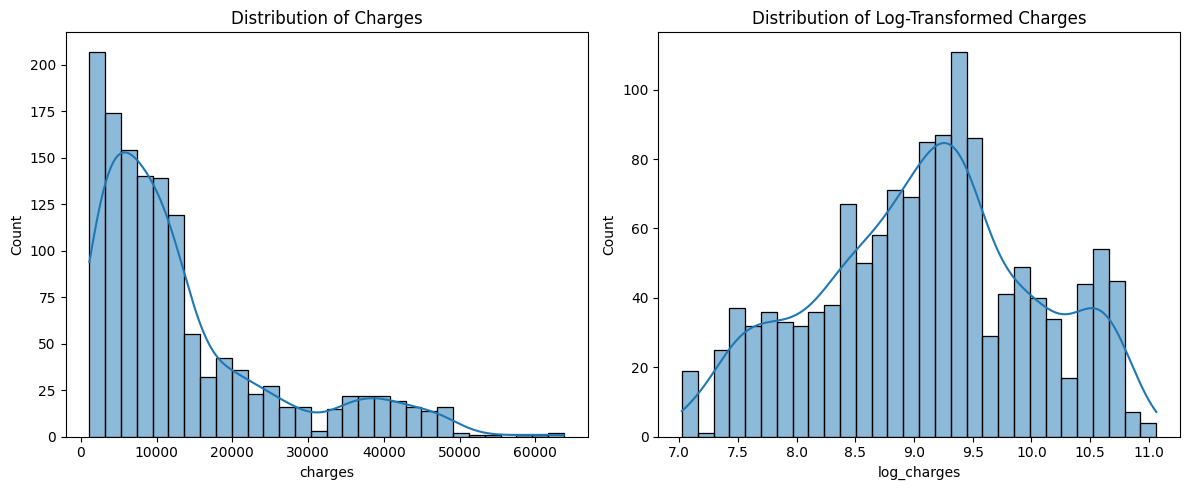

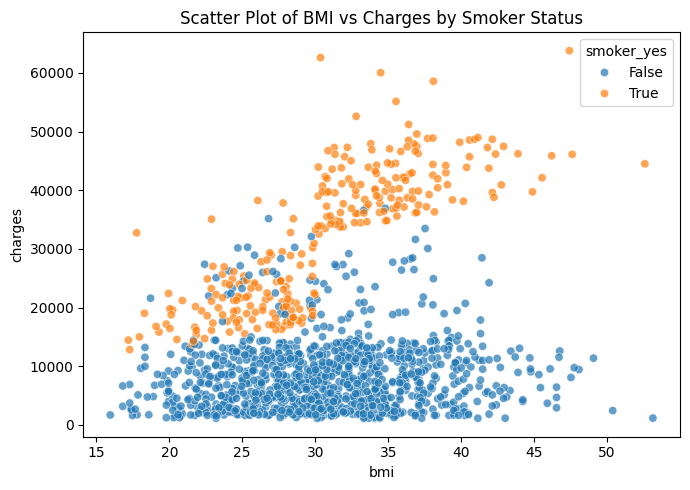

In [30]:
# Exploratory Data Analysis (EDA)
import matplotlib.pyplot as plt
import seaborn as sns
from plotly.subplots import make_subplots
import plotly.graph_objs as go
import plotly.io as pio

# Distribution of 'charges' and 'log_charges'
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['charges'], bins=30, kde=True)
plt.title('Distribution of Charges')

plt.subplot(1, 2, 2)
sns.histplot(df['log_charges'], bins=30, kde=True)
plt.title('Distribution of Log-Transformed Charges')

plt.tight_layout()
plt.show()

# Scatter plot BMI vs Charges
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker_yes', alpha=0.7)
plt.title('Scatter Plot of BMI vs Charges by Smoker Status')
plt.tight_layout()
plt.show()

# Dashboard of charges across bmi_category, smoker status, regions, age groups
age_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']  #define colors for each category
bmi_colors = ['#8c564b', '#e377c2', '#7f7f7f', '#bcbd22']  
smoker_colors = ['#17becf', '#ff9896']  

age_traces = [     #create bar traces for age groups
    go.Bar(
        x=[group],
        y=[value],
        name=f"Age: {group}",
        marker=dict(color=age_colors[i])
    )
    for i, (group, value) in enumerate(avg_charges_by_age_group.items())
]


bmi_traces = [     #create bar traces for BMI categories
    go.Bar(
        x=[group],
        y=[value],
        name=f"BMI: {group}",
        marker=dict(color=bmi_colors[i])
    )
    for i, (group, value) in enumerate(avg_charges_by_bmi_group.items())
]


smoker_traces = [       #create bar traces for smoker status
    go.Bar(
        x=[group],
        y=[value],
        name=f"Smoker: {group}",
        marker=dict(color=smoker_colors[i])
    )
    for i, (group, value) in enumerate(avg_charges_by_smoker.items())
]

pie_trace = go.Pie(              #create pie chart for smoker distribution
    labels=smoker_counts.index,
    values=smoker_counts.values,
    name="Smoker Share",
    marker=dict(colors=smoker_colors),
    hole=0.4,
    showlegend=True
)


dashboard = make_subplots(             #assemble dashboard with subplots                   
    rows=2, cols=2,
    subplot_titles=(
        "Smoker vs Non-Smoker Distribution",
        "Average Charges by Age Group",
        "Average Charges by BMI Category",
        "Average Charges by Smoker Status"
    ),
    specs=[[{"type": "domain"}, {"type": "xy"}],
           [{"type": "xy"}, {"type": "xy"}]]
)


dashboard.add_trace(pie_trace, row=1, col=1)      #add traces to the dashboard
for tr in age_traces:
    dashboard.add_trace(tr, row=1, col=2)
for tr in bmi_traces:
    dashboard.add_trace(tr, row=2, col=1)
for tr in smoker_traces:
    dashboard.add_trace(tr, row=2, col=2)


dashboard.update_layout(     #update layout and axes
    height=800,
    width=1000,
    showlegend=True,
    template="plotly",
    title_text="<b>Healthcare Insurance Charge Dashboard</b>",
    legend_title_text="Legend"
)

dashboard.update_xaxes(title_text="Age Group", row=1, col=2)
dashboard.update_yaxes(title_text="Average Charges", row=1, col=2)
dashboard.update_xaxes(title_text="BMI Category", row=2, col=1)
dashboard.update_yaxes(title_text="Average Charges", row=2, col=1)
dashboard.update_xaxes(title_text="Smoker Status", row=2, col=2)
dashboard.update_yaxes(title_text="Average Charges", row=2, col=2)


dashboard.show() 

pio.write_image(dashboard, "dashboard_static.png", scale=3) #save as static image
    

Correlation Table:
   Variable  Correlation        P-value
0       bmi     0.198401   2.468040e-13
1       age     0.298308   6.975749e-29
2  children     0.067389   1.371703e-02
3       sex     0.058044   3.382079e-02
4    smoker     0.787234  1.406722e-282
5    region     0.080885            NaN


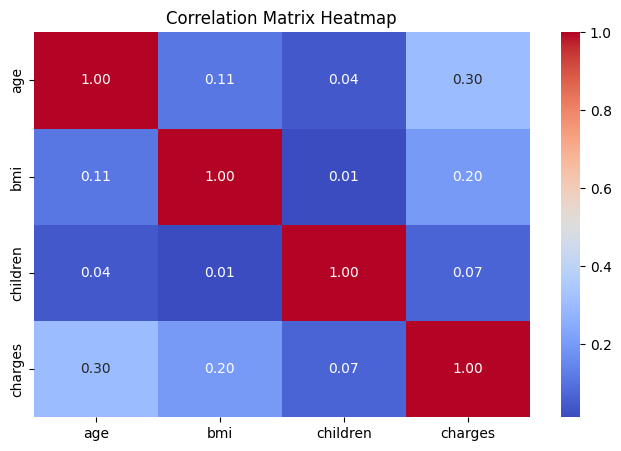

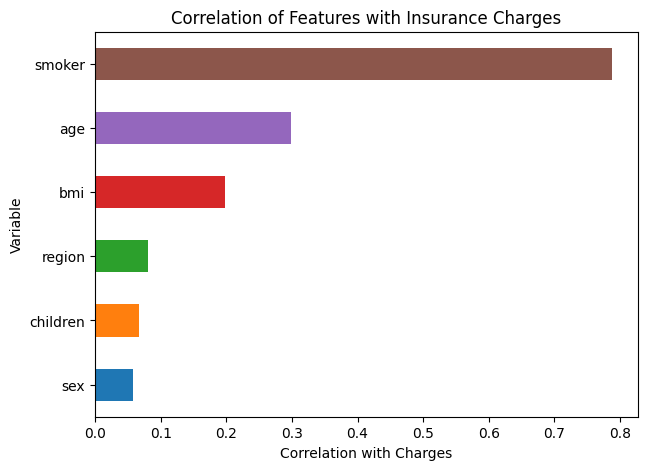

In [31]:
# Correlation Analysis
from scipy.stats import pearsonr, pointbiserialr

#Charges vs Numerical Variables (Pearson)
numeric_cols = ['bmi', 'age', 'children']
numeric_corr = []

for col in numeric_cols:
    corr, p_val = pearsonr(df[col], df['charges'])
    numeric_corr.append({'Variable': col, 'Correlation': corr, 'P-value': p_val})

numeric_corr_df = pd.DataFrame(numeric_corr)

#Charges vs Binary Variables (Point-Biserial)
binary_vars = {'sex_male': 'sex', 'smoker_yes': 'smoker'}
binary_corr = []

for col, display_name in binary_vars.items():
    x_numeric = df[col].astype(int)
    corr, p_val = pointbiserialr(x_numeric, df['charges'])
    binary_corr.append({'Variable': display_name, 'Correlation': corr, 'P-value': p_val})

binary_corr_df = pd.DataFrame(binary_corr)

#Charges vs Multi-category Variable (Region)
def correlation_ratio(categories, measurements):
    fcat, _ = pd.factorize(categories)
    cat_num = np.max(fcat) + 1
    y_avg_array = np.zeros(cat_num)
    n_array = np.zeros(cat_num)
    for i in range(cat_num):
        cat_measures = measurements[np.argwhere(fcat == i).flatten()]
        n_array[i] = len(cat_measures)
        y_avg_array[i] = np.mean(cat_measures) if len(cat_measures) > 0 else 0
    y_total_avg = np.sum(y_avg_array * n_array) / np.sum(n_array)
    numerator = np.sum(n_array * (y_avg_array - y_total_avg) ** 2)
    denominator = np.sum((measurements - y_total_avg) ** 2)
    return np.sqrt(numerator / denominator) if denominator != 0 else 0

# Reconstruct region from one-hot encoded columns
def reconstruct_region(row):
    if row['region_northwest']:
        return 'northwest'
    elif row['region_southeast']:
        return 'southeast'
    elif row['region_southwest']:
        return 'southwest'
    else:
        return 'northeast'

region_reconstructed = df.apply(reconstruct_region, axis=1)
corr_region = correlation_ratio(region_reconstructed, df['charges'].values)
multi_corr_df = pd.DataFrame([{'Variable':'region', 'Correlation': corr_region, 'P-value': np.nan}])

#Correlation Table
corr_table = pd.concat([numeric_corr_df, binary_corr_df, multi_corr_df], ignore_index=True)
print("Correlation Table:")
print(corr_table)

#Heatmap for Numeric Variables
numeric_for_heatmap = [c for c in df.select_dtypes(include='number').columns if c != 'log_charges']
corr_matrix = df[numeric_for_heatmap].corr()

plt.figure(figsize=(8,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()

#Bar Chart for correlation with charges
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']  # one color per variable
corr_charges = corr_table.set_index('Variable')['Correlation'].sort_values()
plt.figure(figsize=(7,5))
corr_charges.plot(kind='barh', color=colors[:len(corr_charges)])
plt.xlabel("Correlation with Charges")
plt.title("Correlation of Features with Insurance Charges")
plt.show()

In [32]:
# Predictive Modeling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y = df['log_charges']     #target variable

feature_cols = [
    'age', 'bmi', 'children', 'sex_male', 'smoker_yes',
    'region_northwest', 'region_southeast', 'region_southwest'    #encoded features
]
X = df[feature_cols].copy()

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(  #split data
    X, y, test_size=0.2, random_state=42              #20% test size
)

# Train Models
rf_model = RandomForestRegressor(n_estimators=300, random_state=42)
rf_model.fit(X_train, y_train)                      
y_pred_rf = rf_model.predict(X_test)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# Evaluation Function
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name} Evaluation (log scale):")
    print(f"MAE:  {mae:.4f}")
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²:   {r2:.4f}")

evaluate(y_test, y_pred_rf, "Random Forest")
evaluate(y_test, y_pred_lr, "Linear Regression")


Random Forest Evaluation (log scale):
MAE:  0.1990
MSE:  0.1435
RMSE: 0.3788
R²:   0.8453

Linear Regression Evaluation (log scale):
MAE:  0.2607
MSE:  0.1582
RMSE: 0.3978
R²:   0.8295


In [33]:
# Predictive Reporting (Random Forest)
pred_df = X_test.copy()
pred_df['Actual_LogCharges'] = y_test 
pred_df['Pred_Log_RF'] = y_pred_rf
pred_df['Actual_Charges'] = np.expm1(pred_df['Actual_LogCharges'])      
pred_df['Pred_RF_Charges'] = np.expm1(pred_df['Pred_Log_RF'])           

# Calculate Error Metrics
pred_df['Abs_Error_RF'] = (pred_df['Actual_Charges'] - pred_df['Pred_RF_Charges']).abs()
pred_df['Pct_Error_RF'] = pred_df['Abs_Error_RF'] / pred_df['Actual_Charges'] * 100

#BMI Category
def bmi_category(b):
    if b < 18.5: return 'Underweight'
    if b < 25: return 'Normal'             
    if b < 30: return 'Overweight'
    return 'Obese'

pred_df['bmi_category'] = pred_df['bmi'].apply(bmi_category)

#Age Group
pred_df['age_group'] = pd.cut(pred_df['age'], bins=[0,18,30,45,60,200],
                              labels=['0-18','19-30','31-45','46-60','61+']) 

#Smoker Status/Sex/Region
pred_df['smoker'] = np.where(pred_df.get('smoker_yes', 0)==1, 'yes', 'no')   
pred_df['sex'] = np.where(pred_df.get('sex_male', 0)==1, 'male', 'female')   
pred_df['region'] = np.select(
    [pred_df.get('region_northwest',0)==1, pred_df.get('region_southeast',0)==1, pred_df.get('region_southwest',0)==1],
    ['northwest','southeast','southwest'],                                   
    default='northeast'                             
)

# Summary Tables 
group_cols = {
  'By smoker': 'smoker',
  'By region': 'region',
  'By age_group': 'age_group',
  'By bmi_category': 'bmi_category'
}
summaries = {}
for title, col in group_cols.items():
    summaries[col] = pred_df.groupby(col, observed=True).agg(
        Actual=('Actual_Charges','mean'),             
        Predicted=('Pred_RF_Charges','mean'),
        MAE=('Abs_Error_RF','mean'),
        PctError=('Pct_Error_RF','mean'),
        Count=('Actual_Charges','count')
    ).round(2)
    display(summaries[col])

X_encoded = X    #feature importance

# Save Full Predictive Report
pred_df.to_csv("predictions_full_report.csv", index=False)


,Actual,Predicted,MAE,PctError,Count
smoker,,,,,
no,8202.99,8034.42,1983.28,24.67,208
yes,35311.26,34451.80,2491.78,6.48,60


,Actual,Predicted,MAE,PctError,Count
region,,,,,
northeast,13995.18,12723.69,2658.67,23.02,71
northwest,14842.25,14591.53,2127.71,19.28,60
southeast,15409.11,15354.68,1818.07,20.49,77
southwest,12570.06,12951.39,1760.15,19.20,60


,Actual,Predicted,MAE,PctError,Count
age_group,,,,,
0-18,5589.60,5646.85,1924.28,58.76,17
19-30,7838.45,7856.57,1748.47,30.91,70
31-45,17471.46,16852.29,2356.64,14.31,79
46-60,16360.88,15938.55,2307.93,13.15,82
61+,22967.28,22700.98,1574.93,7.44,20


,Actual,Predicted,MAE,PctError,Count
bmi_category,,,,,
Normal,9419.42,10530.24,1211.93,17.15,40
Obese,16861.29,16573.00,2163.25,23.54,153
Overweight,11421.26,10358.75,2368.58,16.72,69
Underweight,13379.35,11105.93,3190.42,13.26,6


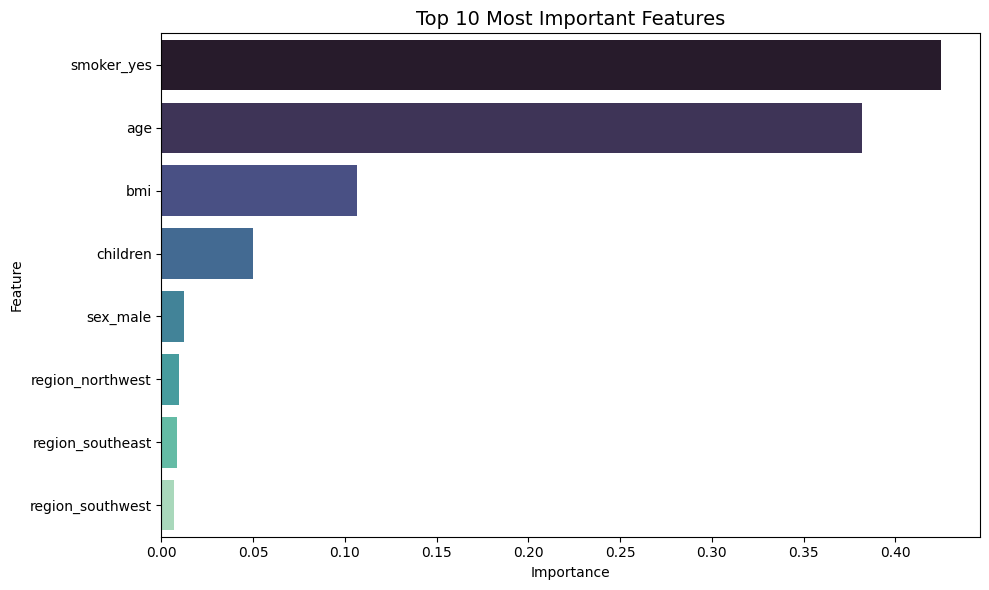

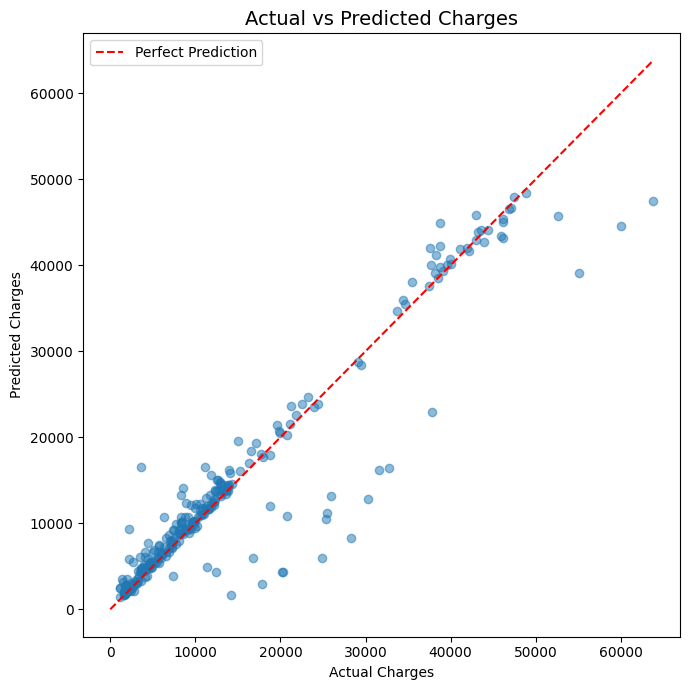

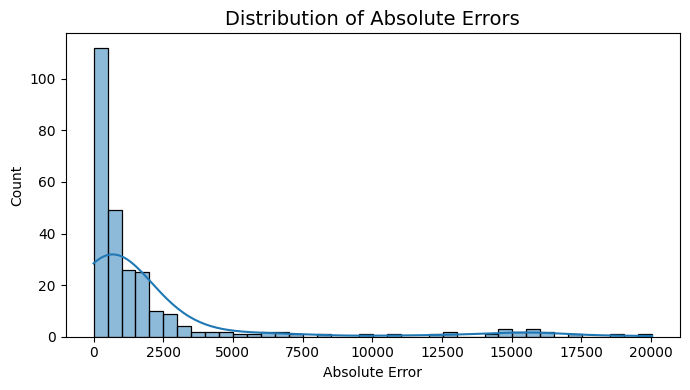

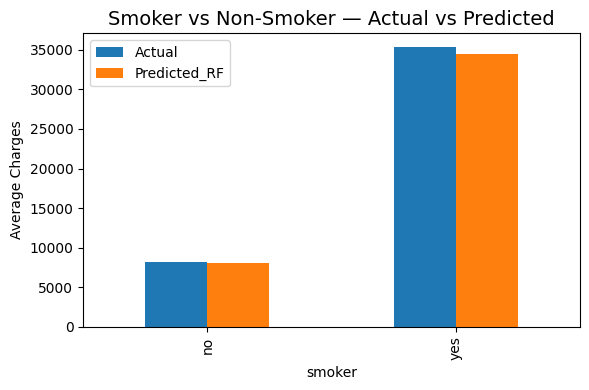

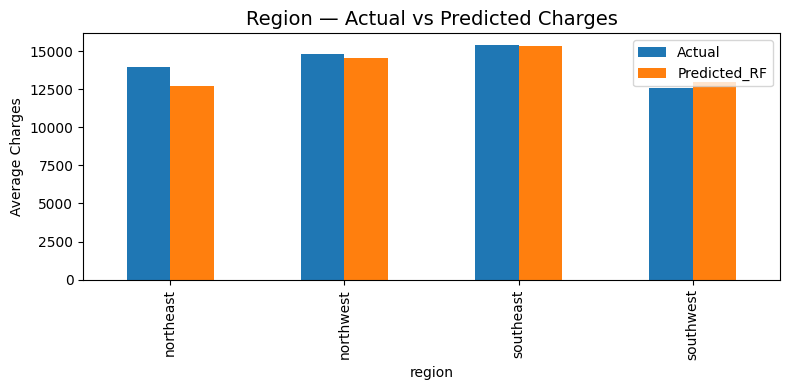

In [34]:
# Feature Importance
feature_importance = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature",
    palette="mako"   
)
plt.title("Top 10 Most Important Features", fontsize=14)
plt.tight_layout()
plt.show()


# Actual vs Predicted (RF)
plt.figure(figsize=(7, 7))
plt.scatter(
    pred_df['Actual_Charges'],
    pred_df['Pred_RF_Charges'],
    alpha=0.5
)

max_val = max(pred_df['Actual_Charges'].max(),
              pred_df['Pred_RF_Charges'].max())

plt.plot([0, max_val], [0, max_val], 'r--', label="Perfect Prediction")

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges", fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()


# Error Distribution (RF)
plt.figure(figsize=(7, 4))
sns.histplot(pred_df['Abs_Error_RF'], bins=40, kde=True)
plt.title("Distribution of Absolute Errors", fontsize=14)
plt.xlabel("Absolute Error")
plt.tight_layout()
plt.show()


# Smoker Group Comparison
smoker_comparison = pred_df.groupby('smoker').agg(
    Actual=('Actual_Charges', 'mean'),
    Predicted_RF=('Pred_RF_Charges', 'mean')
).round(2)

smoker_comparison[['Actual', 'Predicted_RF']].plot(
    kind='bar',
    figsize=(6, 4),
    color=["#1f77b4", "#ff7f0e"]
)

plt.title("Smoker vs Non-Smoker — Actual vs Predicted", fontsize=14)
plt.ylabel("Average Charges")
plt.tight_layout()
plt.show()


# Region Group Comparison
region_comparison = pred_df.groupby('region').agg(
    Actual=('Actual_Charges', 'mean'),
    Predicted_RF=('Pred_RF_Charges', 'mean')
).round(2)

region_comparison[['Actual', 'Predicted_RF']].plot(
    kind='bar',
    figsize=(8, 4),
    color=["#1f77b4", "#ff7f0e"]
)

plt.title("Region — Actual vs Predicted Charges", fontsize=14)
plt.ylabel("Average Charges")
plt.tight_layout()
plt.show()

In [39]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(rf_model, "models/rf_model.pkl")
joblib.dump(list(X_encoded.columns), "models/model_columns.pkl")

print("Saved model and columns!")

Saved model and columns!
